In [ ]:
from google.colab import files
uploaded = files.upload()

Saving stock_prices.csv to stock_prices.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm

In [ ]:
df = pd.read_csv("stock_prices.csv")
df.head()

,date,ticker,open,high,low,close,adjusted_close,volume,sector
0,2014-01-02,AAPL,19.845715,19.893929,19.715000,19.754642,17.253258,234684800,Electronics
1,2014-01-03,AAPL,19.745000,19.775000,19.301071,19.320715,16.874273,392467600,Electronics
2,2014-01-06,AAPL,19.194643,19.528570,19.057142,19.426071,16.966291,412610800,Electronics
3,2014-01-07,AAPL,19.440000,19.498571,19.211430,19.287144,16.844955,317209200,Electronics
4,2014-01-08,AAPL,19.243214,19.484285,19.238930,19.409286,16.951628,258529600,Electronics


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139025 entries, 0 to 139024
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date            139025 non-null  datetime64[ns]
 1   ticker          139025 non-null  object        
 2   open            139025 non-null  float64       
 3   high            139025 non-null  float64       
 4   low             139025 non-null  float64       
 5   close           139025 non-null  float64       
 6   adjusted_close  139025 non-null  float64       
 7   volume          139025 non-null  int64         
 8   sector          139025 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(2)
memory usage: 9.5+ MB


In [ ]:
df.describe()

,open,high,low,close,adjusted_close,volume
count,139025.000000,139025.000000,139025.000000,139025.000000,139025.000000,1.390250e+05
mean,129.603511,130.921044,128.261607,129.629752,121.329193,2.729338e+07
std,117.302405,118.545843,116.005183,117.314735,117.358388,7.635235e+07
min,0.385750,0.388000,0.383000,0.384000,0.362201,-2.119623e+09
25%,51.340000,51.836666,50.830000,51.340000,44.207672,3.839300e+06
50%,97.500000,98.410000,96.600000,97.510000,85.277580,7.880700e+06
75%,161.480000,162.980000,159.931000,161.480000,151.480010,2.074500e+07
max,957.770000,972.530000,951.580000,960.020000,960.020000,2.129096e+09


In [ ]:
print(pd.unique(df["ticker"]))

['AAPL' 'ABBV' 'ABT' 'ACN' 'ADBE' 'AMD' 'AMGN' 'AMZN' 'AVGO' 'BAC' 'CAT'
 'CMCSA' 'COP' 'COST' 'CRM' 'CSCO' 'CVX' 'DHR' 'DIS' 'GOOG' 'GOOGL' 'HD'
 'JNJ' 'JPM' 'KO' 'LIN' 'LLY' 'MA' 'MCD' 'META' 'MRK' 'MS' 'MSFT' 'NFLX'
 'NKE' 'NVDA' 'ORCL' 'PEP' 'PFE' 'PG' 'PM' 'TMO' 'TMUS' 'TSLA' 'TXN' 'UNH'
 'UPS' 'V' 'WFC' 'WMT' 'XOM']


In [ ]:
df["date"] = pd.to_datetime(df["date"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139025 entries, 0 to 139024
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date            139025 non-null  datetime64[ns]
 1   ticker          139025 non-null  object        
 2   open            139025 non-null  float64       
 3   high            139025 non-null  float64       
 4   low             139025 non-null  float64       
 5   close           139025 non-null  float64       
 6   adjusted_close  139025 non-null  float64       
 7   volume          139025 non-null  int64         
 8   sector          139025 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(2)
memory usage: 9.5+ MB


In [ ]:
df["date"][0].weekday()

3

In [ ]:
df["date"][0].day

2

In [ ]:
df["date"][0].year

2014

In [ ]:
appel_stock = df[df["ticker"] == "AAPL"]
appel_stock.head()

,date,ticker,open,high,low,close,adjusted_close,volume,sector
0,2014-01-02,AAPL,19.845715,19.893929,19.715000,19.754642,17.253258,234684800,Electronics
1,2014-01-03,AAPL,19.745000,19.775000,19.301071,19.320715,16.874273,392467600,Electronics
2,2014-01-06,AAPL,19.194643,19.528570,19.057142,19.426071,16.966291,412610800,Electronics
3,2014-01-07,AAPL,19.440000,19.498571,19.211430,19.287144,16.844955,317209200,Electronics
4,2014-01-08,AAPL,19.243214,19.484285,19.238930,19.409286,16.951628,258529600,Electronics


In [ ]:
appel_stock.set_index("date", inplace=True)

In [ ]:
appel_stock.head()

,ticker,open,high,low,close,adjusted_close,volume,sector
date,,,,,,,,
2014-01-02,AAPL,19.845715,19.893929,19.715000,19.754642,17.253258,234684800,Electronics
2014-01-03,AAPL,19.745000,19.775000,19.301071,19.320715,16.874273,392467600,Electronics
2014-01-06,AAPL,19.194643,19.528570,19.057142,19.426071,16.966291,412610800,Electronics
2014-01-07,AAPL,19.440000,19.498571,19.211430,19.287144,16.844955,317209200,Electronics
2014-01-08,AAPL,19.243214,19.484285,19.238930,19.409286,16.951628,258529600,Electronics


In [ ]:
appel_stock_feb_2020 = appel_stock.loc["2020-02-01":"2020-02-28"]
appel_stock_feb_2020

,ticker,open,high,low,close,adjusted_close,volume,sector
date,,,,,,,,
2020-02-03,AAPL,76.0750,78.3725,75.5550,77.1650,74.892440,173788400,Electronics
2020-02-04,AAPL,78.8275,79.9100,78.4075,79.7125,77.364890,136616400,Electronics
2020-02-05,AAPL,80.8800,81.1900,79.7375,80.3625,77.995760,118826800,Electronics
2020-02-06,AAPL,80.6425,81.3050,80.0650,81.3025,78.908070,105425600,Electronics
2020-02-07,AAPL,80.5925,80.8500,79.5000,80.0075,77.835510,117684000,Electronics
2020-02-10,AAPL,78.5450,80.3875,78.4625,80.3875,78.205185,109348800,Electronics
2020-02-11,AAPL,80.9000,80.9750,79.6775,79.9025,77.733350,94323200,Electronics
2020-02-12,AAPL,80.3675,81.8050,80.3675,81.8000,79.579340,113730400,Electronics
2020-02-13,AAPL,81.0475,81.5550,80.8375,81.2175,79.012650,94747600,Electronics


In [ ]:
appel_stock_jan_2020 = appel_stock.loc["2020-01-01":"2020-01-31"]
appel_stock_jan_2020

,ticker,open,high,low,close,adjusted_close,volume,sector
date,,,,,,,,
2020-01-02,AAPL,74.0600,75.1500,73.7975,75.0875,72.876114,135480400,Electronics
2020-01-03,AAPL,74.2875,75.1450,74.1250,74.3575,72.167610,146322800,Electronics
2020-01-06,AAPL,73.4475,74.9900,73.1875,74.9500,72.742650,118387200,Electronics
2020-01-07,AAPL,74.9600,75.2250,74.3700,74.5975,72.400536,108872000,Electronics
2020-01-08,AAPL,74.2900,76.1100,74.2900,75.7975,73.565210,132079200,Electronics
2020-01-09,AAPL,76.8100,77.6075,76.5500,77.4075,75.127790,170108400,Electronics
2020-01-10,AAPL,77.6500,78.1675,77.0625,77.5825,75.297640,140644800,Electronics
2020-01-13,AAPL,77.9100,79.2675,77.7875,79.2400,76.906320,121532000,Electronics
2020-01-14,AAPL,79.1750,79.3925,78.0425,78.1700,75.867830,161954400,Electronics


In [ ]:
appel_stock_mar_2020 = appel_stock.loc["2020-03-01":"2020-03-31"]
appel_stock_mar_2020

,ticker,open,high,low,close,adjusted_close,volume,sector
date,,,,,,,,
2020-03-02,AAPL,70.5700,75.3600,69.4300,74.7025,72.674510,341397200,Electronics
2020-03-03,AAPL,75.9175,76.0000,71.4500,72.3300,70.366420,319475600,Electronics
2020-03-04,AAPL,74.1100,75.8500,73.2825,75.6850,73.630350,219178400,Electronics
2020-03-05,AAPL,73.8800,74.8875,72.8525,73.2300,71.241990,187572800,Electronics
2020-03-06,AAPL,70.5000,72.7050,70.3075,72.2575,70.295910,226176800,Electronics
2020-03-09,AAPL,65.9375,69.5225,65.7500,66.5425,64.736046,286744800,Electronics
2020-03-10,AAPL,69.2850,71.6100,67.3425,71.3350,69.398430,285290000,Electronics
2020-03-11,AAPL,69.3475,70.3050,67.9650,68.8575,66.988180,255598800,Electronics
2020-03-12,AAPL,63.9850,67.5000,62.0000,62.0575,60.372800,418474000,Electronics


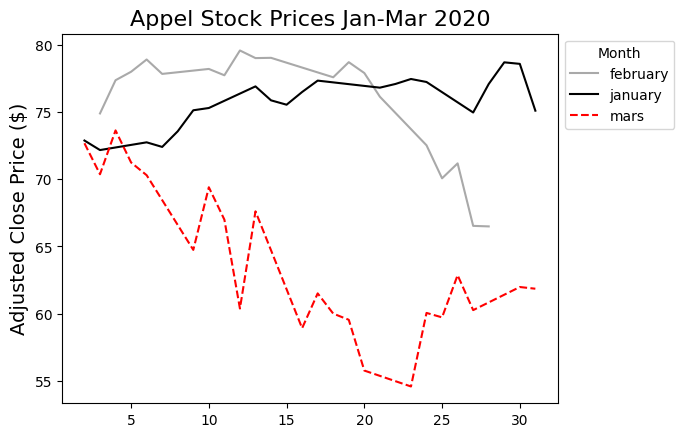

In [ ]:
sns.lineplot(x=appel_stock_feb_2020.index.day,
    y=appel_stock_feb_2020["adjusted_close"], color="darkgray", label="february")

sns.lineplot(x=appel_stock_jan_2020.index.day,
    y=appel_stock_jan_2020["adjusted_close"], color="black", label="january")

sns.lineplot(x=appel_stock_mar_2020.index.day,
    y=appel_stock_mar_2020["adjusted_close"],color="red", linestyle="--", label="mars")
plt.title("Appel Stock Prices Jan-Mar 2020", fontsize=16)
plt.xlabel("")
plt.ylabel("Adjusted Close Price ($)", fontsize=14)
plt.legend(title="Month", bbox_to_anchor=(1, 1))
plt.show()

In [ ]:
# Set up amazon stocks
amazon_stocks = df[df["ticker"] == "AMZN"]
amazon_stocks.head()

,date,ticker,open,high,low,close,adjusted_close,volume,sector
19081,2014-01-02,AMZN,19.9400,19.9680,19.7010,19.8985,19.8985,42756000,Retail
19082,2014-01-03,AMZN,19.9145,20.1355,19.8110,19.8220,19.8220,44204000,Retail
19083,2014-01-06,AMZN,19.7925,19.8500,19.4210,19.6815,19.6815,63412000,Retail
19084,2014-01-07,AMZN,19.7520,19.9235,19.7145,19.9015,19.9015,38320000,Retail
19085,2014-01-08,AMZN,19.9235,20.1500,19.8020,20.0960,20.0960,46330000,Retail


In [ ]:
amazon_stocks.set_index("date", inplace=True)

In [ ]:
amazon_stocks.head()

,ticker,open,high,low,close,adjusted_close,volume,sector
date,,,,,,,,
2014-01-02,AMZN,19.9400,19.9680,19.7010,19.8985,19.8985,42756000,Retail
2014-01-03,AMZN,19.9145,20.1355,19.8110,19.8220,19.8220,44204000,Retail
2014-01-06,AMZN,19.7925,19.8500,19.4210,19.6815,19.6815,63412000,Retail
2014-01-07,AMZN,19.7520,19.9235,19.7145,19.9015,19.9015,38320000,Retail
2014-01-08,AMZN,19.9235,20.1500,19.8020,20.0960,20.0960,46330000,Retail


In [ ]:
import matplotlib.dates as mdates

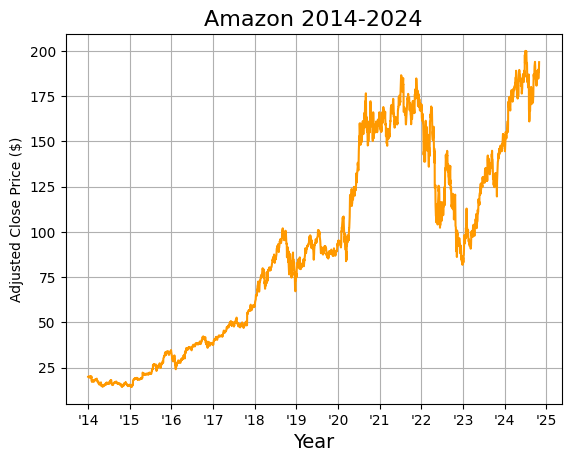

In [ ]:
ax = sns.lineplot(amazon_stocks["adjusted_close"], color="#FF9900")
plt.title("Amazon 2014-2024", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Adjusted Close Price ($)")
plt.grid()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("'%y"))
plt.show()

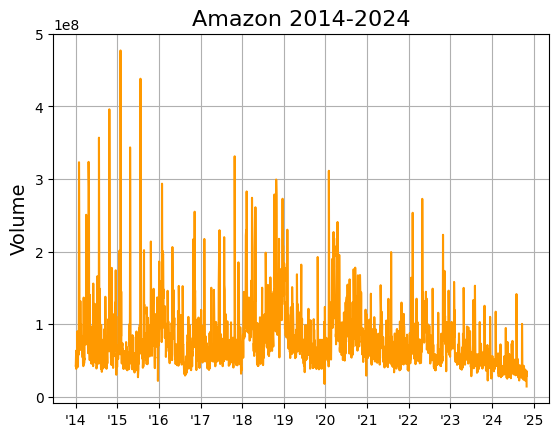

In [ ]:
ax = sns.lineplot(amazon_stocks["volume"], color="#FF9900")
plt.title("Amazon 2014-2024", fontsize=16)
plt.xlabel("", fontsize=14)
plt.ylabel("Volume", fontsize=14)
plt.grid()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("'%y"))
plt.show()

In [ ]:
# Calculate the moving average
amazon_stocks["volume"].rolling(window=14)

Rolling [window=14,center=False,axis=0,method=single]

In [ ]:
amazon_volume_14days = amazon_stocks["volume"].rolling(window=14).mean()

In [ ]:
amazon_volume_14days[:14]

,volume
date,
2014-01-02,NaN
2014-01-03,NaN
2014-01-06,NaN
2014-01-07,NaN
2014-01-08,NaN
2014-01-09,NaN
2014-01-10,NaN
2014-01-13,NaN
2014-01-14,NaN


In [ ]:
amazon_volume_90days = amazon_stocks["volume"].rolling(window=90).mean()

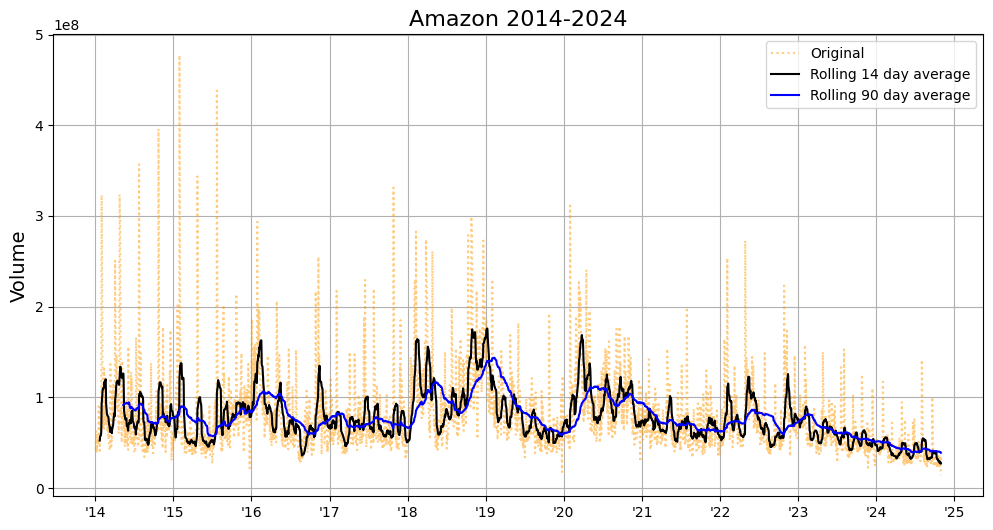

In [ ]:
plt.figure(figsize=(12,6))
ax = sns.lineplot(amazon_stocks["volume"], color="#FF9900", alpha=0.5, linestyle=":", label="Original")
sns.lineplot(amazon_volume_14days, color="black", label="Rolling 14 day average")
sns.lineplot(amazon_volume_90days, color="blue", label="Rolling 90 day average")
plt.title("Amazon 2014-2024", fontsize=16)
plt.xlabel("", fontsize=14)
plt.ylabel("Volume", fontsize=14)
plt.grid()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("'%y"))
plt.show()

In [ ]:
# Investigate adjusted close price
amazon_close_pct_change = amazon_stocks["adjusted_close"].pct_change()
amazon_close_pct_change.head()

,adjusted_close
date,
2014-01-02,NaN
2014-01-03,-0.003845
2014-01-06,-0.007088
2014-01-07,0.011178
2014-01-08,0.009773


In [ ]:
amazon_close_pct_change * 100

,adjusted_close
date,
2014-01-02,NaN
2014-01-03,-0.384451
2014-01-06,-0.708808
2014-01-07,1.117801
2014-01-08,0.977313
...,...
2024-10-24,0.904120
2024-10-25,0.777980
2024-10-28,0.298142


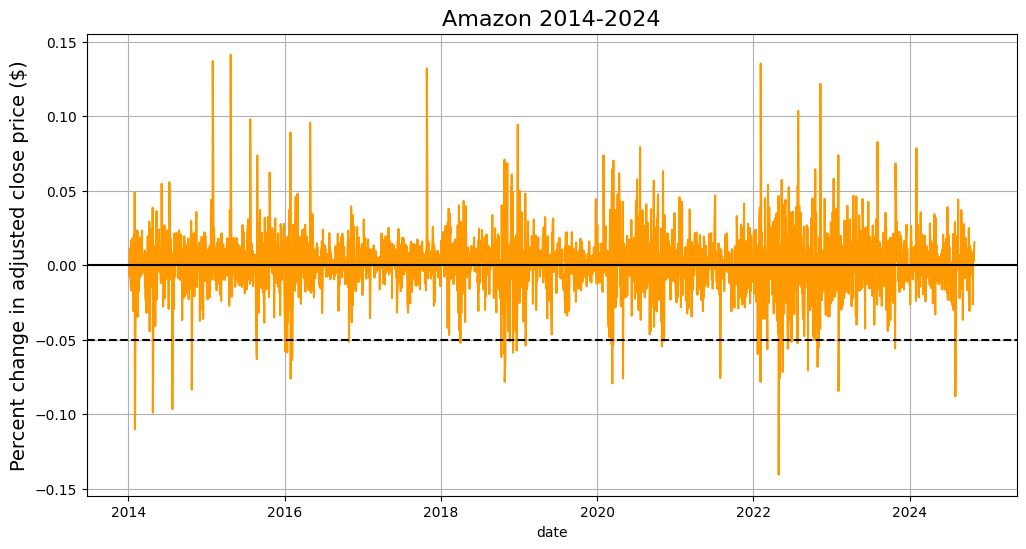

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(amazon_close_pct_change, color="#FF9900")
plt.title("Amazon 2014-2024", fontsize=16)
plt.ylabel("Percent change in adjusted close price ($)", fontsize=14)
plt.axhline(y=-0.05, color="black", linestyle="--")
plt.axhline(y=0, color="black", linestyle="-")
plt.grid()
plt.show()

In [ ]:
dips = amazon_close_pct_change[amazon_close_pct_change < -0.05]

In [ ]:
dips.count()

np.int64(44)

In [ ]:
len(dips)

44

In [ ]:
len(amazon_stocks)

2726

In [ ]:
(len(dips) / len(amazon_stocks))*100

1.6140865737344092

In [ ]:
dips.count() / amazon_stocks.count()

,0
ticker,0.016141
open,0.016141
high,0.016141
low,0.016141
close,0.016141
adjusted_close,0.016141
volume,0.016141
sector,0.016141


In [ ]:
print(dips.index)

DatetimeIndex(['2014-01-31', '2014-04-25', '2014-07-25', '2014-10-24',
               '2015-08-24', '2016-01-04', '2016-01-13', '2016-01-29',
               '2016-02-05', '2016-10-28', '2018-04-02', '2018-10-10',
               '2018-10-24', '2018-10-26', '2018-10-29', '2018-11-19',
               '2018-12-04', '2018-12-21', '2019-02-01', '2020-03-09',
               '2020-03-12', '2020-03-16', '2020-05-01', '2020-10-30',
               '2020-11-09', '2021-07-30', '2022-01-21', '2022-02-03',
               '2022-03-07', '2022-04-29', '2022-05-05', '2022-05-09',
               '2022-05-18', '2022-06-10', '2022-06-13', '2022-06-28',
               '2022-07-26', '2022-09-13', '2022-10-14', '2022-10-28',
               '2022-11-01', '2023-02-03', '2023-10-25', '2024-08-02'],
              dtype='datetime64[ns]', name='date', freq=None)


In [ ]:
netflix_stocks = df[df["ticker"] == "NFLX"]

In [ ]:
netflix_stocks.set_index(netflix_stocks["date"], inplace=True)

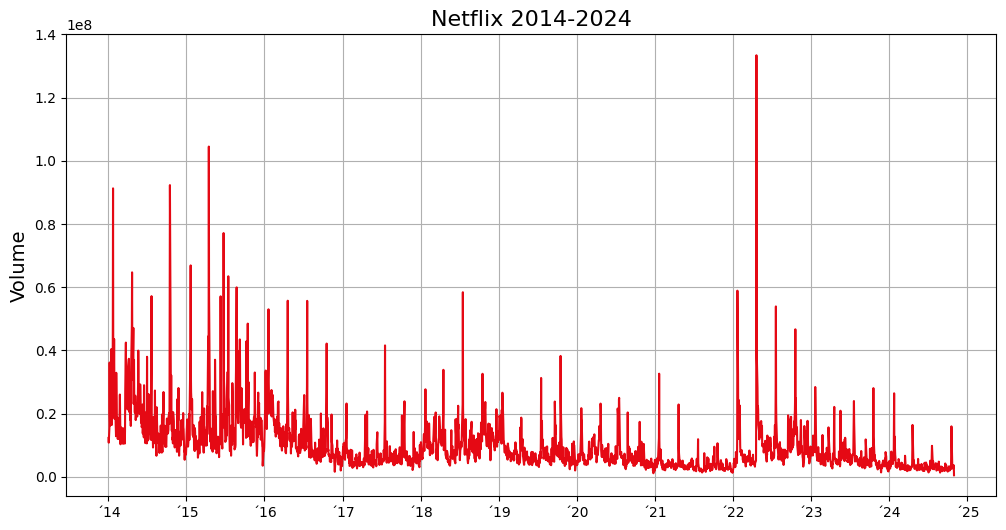

In [ ]:
plt.figure(figsize=(12,6))
ax = sns.lineplot(netflix_stocks["volume"], color="#E50914")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("´%y"))
plt.title("Netflix 2014-2024", fontsize=16)
plt.xlabel("", fontsize=14)
plt.ylabel("Volume",fontsize=14)
plt.grid()
plt.show()

In [ ]:
netflix_stocks.index.month

Index([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       ...
       10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
      dtype='int32', name='date', length=2726)

In [ ]:
print(pd.unique(netflix_stocks.index.month))

[ 1  2  3  4  5  6  7  8  9 10 11 12]


In [ ]:
netflix_stocks["month"] = netflix_stocks.index.month

/tmp/ipykernel_4437/325231307.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netflix_stocks["month"] = netflix_stocks.index.month


In [ ]:
netflix_stocks.head()

,date,ticker,open,high,low,close,adjusted_close,volume,sector,month
date,,,,,,,,,,
2014-01-02,2014-01-02,NFLX,52.401430,52.511430,51.542860,51.831430,51.831430,12325600,Tech Services,1
2014-01-03,2014-01-03,NFLX,52.000000,52.495712,51.842857,51.871430,51.871430,10817100,Tech Services,1
2014-01-06,2014-01-06,NFLX,51.890000,52.044285,50.475716,51.367140,51.367140,15501500,Tech Services,1
2014-01-07,2014-01-07,NFLX,49.684284,49.698570,48.152860,48.500000,48.500000,36167600,Tech Services,1
2014-01-08,2014-01-08,NFLX,48.104286,49.425713,48.074287,48.712856,48.712856,20001100,Tech Services,1


In [ ]:
monthly_volume = netflix_stocks.groupby("month")["volume"].mean()
monthly_volume

,volume
month,
1,1.410399e+07
2,8.827254e+06
3,8.982469e+06
4,1.337481e+07
5,9.103363e+06
6,9.102217e+06
7,1.152011e+07
8,7.832642e+06
9,8.806715e+06


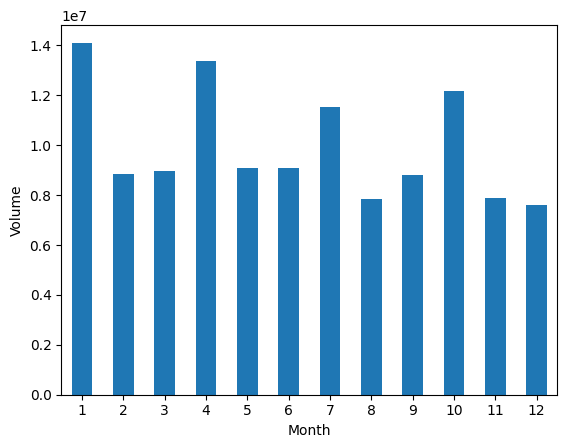

In [ ]:
monthly_volume.plot(kind="bar")
plt.xlabel("Month")
plt.ylabel("Volume")
plt.xticks(rotation=0)
plt.show()

/tmp/ipykernel_4437/2029909040.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(netflix_stocks, x="month", y="volume", palette=colors)


<Axes: xlabel='month', ylabel='volume'>

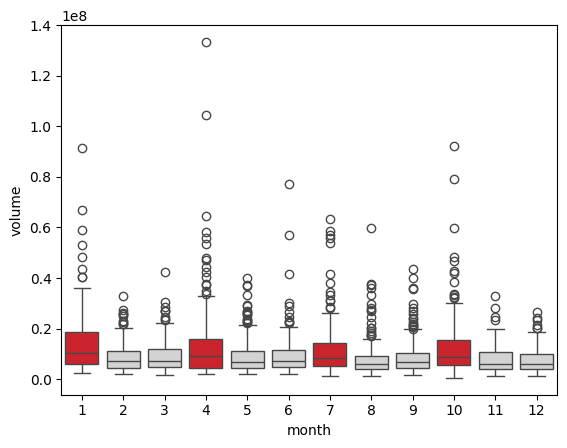

In [ ]:
colors = [
    "#E50914", "lightgray", "lightgray",
    "#E50914", "lightgray", "lightgray",
    "#E50914", "lightgray", "lightgray",
    "#E50914", "lightgray", "lightgray"
]
sns.boxplot(netflix_stocks, x="month", y="volume", palette=colors)

/tmp/ipykernel_4437/2091154053.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(netflix_stocks, x="month", y="volume", palette=colors)


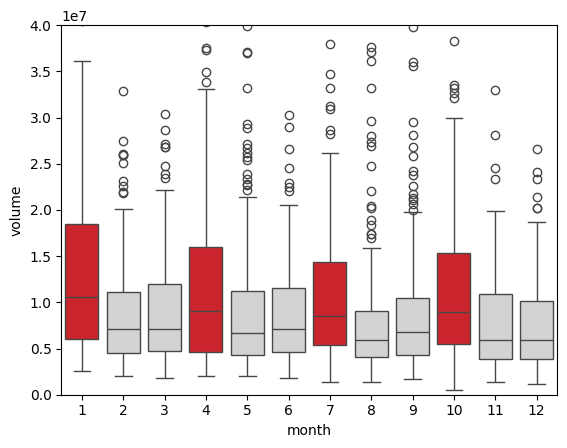

In [ ]:
sns.boxplot(netflix_stocks, x="month", y="volume", palette=colors)
plt.ylim(0, 40000000)
plt.show()

In [ ]:
# Filter for one ticker
df[df["ticker"] == "AAPL"]

,date,ticker,open,high,low,close,adjusted_close,volume,sector
0,2014-01-02,AAPL,19.845715,19.893929,19.715000,19.754642,17.253258,234684800,Electronics
1,2014-01-03,AAPL,19.745000,19.775000,19.301071,19.320715,16.874273,392467600,Electronics
2,2014-01-06,AAPL,19.194643,19.528570,19.057142,19.426071,16.966291,412610800,Electronics
3,2014-01-07,AAPL,19.440000,19.498571,19.211430,19.287144,16.844955,317209200,Electronics
4,2014-01-08,AAPL,19.243214,19.484285,19.238930,19.409286,16.951628,258529600,Electronics
...,...,...,...,...,...,...,...,...,...
2721,2024-10-24,AAPL,229.980000,230.820000,228.410000,230.570000,230.570000,31109500,Electronics
2722,2024-10-25,AAPL,229.740000,233.220000,229.570000,231.410000,231.410000,38802300,Electronics
2723,2024-10-28,AAPL,233.320000,234.730000,232.550000,233.400000,233.400000,36087100,Electronics
2724,2024-10-29,AAPL,233.100000,234.330000,232.320000,233.670000,233.670000,35332800,Electronics


In [ ]:
# Filter for multiple tickers
tickers = ["AAPL","AMZN"]
selected_stocks = df[df["ticker"].isin(tickers)]

In [ ]:
print(pd.unique(selected_stocks["ticker"]))

['AAPL' 'AMZN']


In [ ]:
selected_stocks.sample(10)

,date,ticker,open,high,low,close,adjusted_close,volume,sector
20249,2018-08-22,AMZN,93.8320,95.2900,93.8320,95.2450,95.245000,61610000,Retail
237,2014-12-10,AAPL,28.6025,28.7125,27.8850,27.9875,24.958055,178261200,Electronics
21669,2024-04-16,AMZN,183.2700,184.8300,182.2600,183.3200,183.320000,32891300,Retail
19579,2015-12-23,AMZN,33.3250,33.3300,32.8315,33.1850,33.185000,54458000,Retail
21732,2024-07-17,AMZN,191.3500,191.5800,185.9900,187.9300,187.930000,48076100,Retail
20290,2018-10-19,AMZN,89.2580,90.4550,87.6500,88.2015,88.201500,118144000,Retail
2456,2023-10-05,AAPL,173.7900,175.4500,172.6800,174.9100,174.019520,48527900,Electronics
20812,2020-11-16,AMZN,154.6600,157.1350,153.6345,156.5530,156.553000,76174000,Retail
20471,2019-07-12,AMZN,100.4135,100.8500,100.1935,100.5500,100.550000,50186000,Retail
19977,2017-07-25,AMZN,51.9025,52.1665,51.6240,51.9935,51.993500,48952000,Retail


In [ ]:
# Intersted in the adjusted close for APPEL and AMAZON
# datetime      AAPL     AMZN
# 2018-08-02    100       85
# Need to .pivot() your data
pivoted_stocks = selected_stocks.pivot_table(index="date",
                            columns="ticker",
                            values="adjusted_close")
pivoted_stocks.head()

ticker,AAPL,AMZN
date,,
2014-01-02,17.253258,19.8985
2014-01-03,16.874273,19.8220
2014-01-06,16.966291,19.6815
2014-01-07,16.844955,19.9015
2014-01-08,16.951628,20.0960


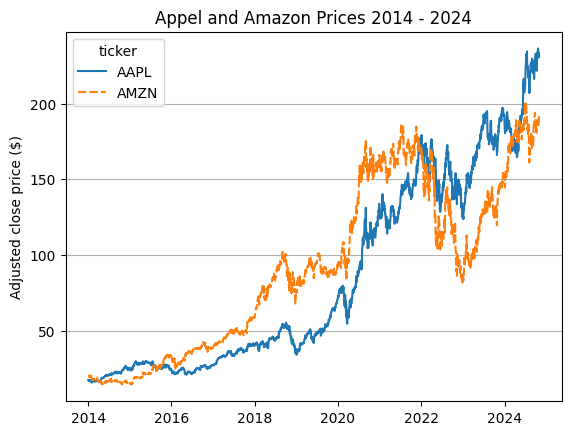

In [ ]:
sns.lineplot(pivoted_stocks)
plt.title("Appel and Amazon Prices 2014 - 2024")
plt.xlabel("")
plt.ylabel("Adjusted close price ($)")
plt.grid(axis="y")
plt.show()

In [ ]:
tickers = ["AAPL", "AMZN" , "NFLX", "NKE", "MSFT"]
selected_tickers = df[df["ticker"].isin(tickers)]
selected_tickers.head()

,date,ticker,open,high,low,close,adjusted_close,volume,sector
0,2014-01-02,AAPL,19.845715,19.893929,19.715000,19.754642,17.253258,234684800,Electronics
1,2014-01-03,AAPL,19.745000,19.775000,19.301071,19.320715,16.874273,392467600,Electronics
2,2014-01-06,AAPL,19.194643,19.528570,19.057142,19.426071,16.966291,412610800,Electronics
3,2014-01-07,AAPL,19.440000,19.498571,19.211430,19.287144,16.844955,317209200,Electronics
4,2014-01-08,AAPL,19.243214,19.484285,19.238930,19.409286,16.951628,258529600,Electronics


In [ ]:
pivoted_stocks = selected_tickers.pivot_table(index="date",
                             columns="ticker",
                             values="adjusted_close")

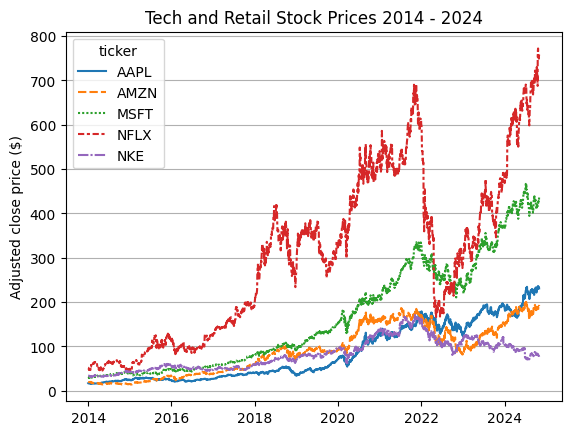

In [ ]:
sns.lineplot(pivoted_stocks)
plt.title("Tech and Retail Stock Prices 2014 - 2024")
plt.xlabel("")
plt.ylabel("Adjusted close price ($)")
plt.grid(axis="y")
plt.show()

In [ ]:
nike_stocks = df[df["ticker"] == "NKE"]
nike_stocks.set_index(nike_stocks["date"], inplace=True)

In [ ]:
nike_stocks.head()

,date,ticker,open,high,low,close,adjusted_close,volume,sector
date,,,,,,,,,
2014-01-02,2014-01-02,NKE,39.075,39.415,38.965,39.120,34.626877,5318600,Consumer Packaged Goods
2014-01-03,2014-01-03,NKE,39.075,39.315,38.980,39.015,34.533930,5597000,Consumer Packaged Goods
2014-01-06,2014-01-06,NKE,39.235,39.300,38.705,38.715,34.268394,6045800,Consumer Packaged Goods
2014-01-07,2014-01-07,NKE,38.855,39.000,38.705,38.745,34.294937,6769000,Consumer Packaged Goods
2014-01-08,2014-01-08,NKE,38.750,38.975,38.465,38.545,34.117910,6897800,Consumer Packaged Goods


In [ ]:
nike_stocks.resample("w")

/tmp/ipykernel_1895/433030707.py:1: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  nike_stocks.resample("w")


In [ ]:
numeric_data = nike_stocks.select_dtypes(include="number")
numeric_data.head()

,open,high,low,close,adjusted_close,volume
date,,,,,,
2014-01-02,39.075,39.415,38.965,39.120,34.626877,5318600
2014-01-03,39.075,39.315,38.980,39.015,34.533930,5597000
2014-01-06,39.235,39.300,38.705,38.715,34.268394,6045800
2014-01-07,38.855,39.000,38.705,38.745,34.294937,6769000
2014-01-08,38.750,38.975,38.465,38.545,34.117910,6897800


In [ ]:
nike_weekly = numeric_data.resample("w").mean()

/tmp/ipykernel_1895/3305876972.py:1: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  nike_weekly = numeric_data.resample("w").mean()


In [ ]:
numeric_data.head()

,open,high,low,close,adjusted_close,volume
date,,,,,,
2014-01-02,39.075,39.415,38.965,39.120,34.626877,5318600
2014-01-03,39.075,39.315,38.980,39.015,34.533930,5597000
2014-01-06,39.235,39.300,38.705,38.715,34.268394,6045800
2014-01-07,38.855,39.000,38.705,38.745,34.294937,6769000
2014-01-08,38.750,38.975,38.465,38.545,34.117910,6897800


In [ ]:
nike_weekly.head()

,open,high,low,close,adjusted_close,volume
date,,,,,,
2014-01-05,39.075,39.3650,38.97250,39.06750,34.580404,5457800.0
2014-01-12,38.810,38.9360,38.52100,38.60200,34.168365,6216760.0
2014-01-19,37.701,37.8110,37.25200,37.39600,33.100880,7324600.0
2014-01-26,36.675,36.8125,36.32125,36.45375,32.266854,9822050.0
2014-02-02,36.195,36.5490,36.01200,36.31700,32.145812,10012000.0


In [ ]:
numeric_data.resample("ME").mean()

,open,high,low,close,adjusted_close,volume
date,,,,,,
2014-01-31,37.541905,37.736190,37.245476,37.405952,33.109691,7.998600e+06
2014-02-28,37.207895,37.588158,37.020000,37.359737,33.079962,7.204221e+06
2014-03-31,38.686429,38.924762,38.331429,38.557381,34.233641,8.501514e+06
2014-04-30,36.634762,36.905952,36.273571,36.526190,32.430226,7.910781e+06
2014-05-31,37.022857,37.293810,36.820476,37.111190,32.959854,5.402095e+06
...,...,...,...,...,...,...
2024-06-30,93.996842,95.097368,93.080000,94.048421,93.630778,1.613395e+07
2024-07-31,73.543182,74.314091,72.781364,73.487273,73.160936,1.799413e+07
2024-08-31,79.147273,80.094091,78.416364,79.434545,79.081798,1.139772e+07


In [ ]:
numeric_data.resample("W-MON").mean()

,open,high,low,close,adjusted_close,volume
date,,,,,,
2014-01-06,39.128333,39.343333,38.883333,38.9500,34.476400,5653800.0
2014-01-13,38.646000,38.768000,38.280000,38.3770,33.969207,6660080.0
2014-01-20,37.522500,37.648750,37.190000,37.3475,33.057949,7090150.0
2014-01-27,36.531000,36.676000,36.229000,36.3530,32.177677,10139960.0
2014-02-03,36.280000,36.602000,35.918000,36.2150,32.055525,9632880.0
...,...,...,...,...,...,...
2024-10-07,83.612000,84.932000,82.730000,83.4820,83.482000,19013200.0
2024-10-14,81.866000,82.422000,81.002000,81.8140,81.814000,9807840.0
2024-10-21,82.786000,83.722000,82.110000,82.7720,82.772000,9398900.0


In [ ]:
nike_stocks.resample("W").first()

,date,ticker,open,high,low,close,adjusted_close,volume,sector
date,,,,,,,,,
2014-01-05,2014-01-02,NKE,39.075,39.415,38.965,39.120,34.626877,5318600,Consumer Packaged Goods
2014-01-12,2014-01-06,NKE,39.235,39.300,38.705,38.715,34.268394,6045800,Consumer Packaged Goods
2014-01-19,2014-01-13,NKE,38.415,38.460,37.500,37.590,33.272602,8262400,Consumer Packaged Goods
2014-01-26,2014-01-21,NKE,37.070,37.300,36.705,36.875,32.639725,13147000,Consumer Packaged Goods
2014-02-02,2014-01-27,NKE,35.955,36.130,35.860,35.950,31.820970,11411600,Consumer Packaged Goods
...,...,...,...,...,...,...,...,...,...
2024-10-06,2024-09-30,NKE,89.700,89.750,87.730,88.400,88.400000,12027100,Consumer Packaged Goods
2024-10-13,2024-10-07,NKE,82.140,82.470,80.090,80.830,80.830000,12767400,Consumer Packaged Goods
2024-10-20,2024-10-14,NKE,82.000,82.040,80.800,81.600,81.600000,8177700,Consumer Packaged Goods
